In [ ]:
!pip install git+https://github.com/strath-ai/SatelliteCloudGenerator

In [2]:
import satellite_cloud_generator as scg
import rasterio as rio
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# test the tifs provided by the authors
clean_img = "geotiffs/cloud_generator_examples/clean.tif"
cloudy_img = "geotiffs/cloud_generator_examples/cloudy.tif"
mask_img = "geotiffs/cloud_generator_examples/mask.tif"

with rio.open(clean_img, 'r') as clean_data:
    #data = clean_data.read(0)
    print(clean_data.shape)
    #print(np.unique(clean_data.read(12)))

with rio.open(cloudy_img, 'r') as cloudy_data:
    print(cloudy_data.shape) 
    #print(np.unique(cloudy_data.read(10)))   

(256, 256)
(256, 256)


In [4]:
import torch

def q_mag(reference,mask,mask_cloudy=None, clean=None,q=0.95,q2=None):
    """ Extract ratios of quantiles
    
        Args:
            reference (Tensor) : input reference image containing cloud [height, width, channels]  

            mask (Tensor) : mask, where 0.0 indicates a clear pixel (if mask_cloudy is provided, 1.0 indicates a clear pixel)
            
            mask_cloudy (Tensor) : optional mask, where 1.0 indicates cloud

            clean (Tensor) : optional image for multiplying the ratios by
            
            q (float) : quantile value used for the cloudy region
            
            q2 (float) : optional quantile value used for the clear region (if unspecifed, it is equal to q)
            
        Returns:
    
            Tensor: Tensor containing cloud magnitudes (or ratios if clean==None)
    
    """
    if mask_cloudy is None:
        mask_clean=mask.squeeze()==0.0 
        mask_cloudy=mask.squeeze()!=0.0 
    else:  
        mask_clean=mask
        mask_cloudy=mask_cloudy
    
    full_cloud=(mask_clean!=1.0).all()
    no_cloud=(mask_cloudy==0.0).all()
   
    if no_cloud:
        return None

    if q2 is None:
        q2=q
    
    # coef per band
    band_coefs=[]
    for idx in range(reference.shape[-3]):
        
        i=reference.index_select(-3,torch.tensor(idx,device=reference.device))

        cloud_val=(i[mask_cloudy]).quantile(q)
        clear_val=(i[mask_clean]).quantile(q2) if not full_cloud else 1

        band_coefs.append(cloud_val/clear_val)
        
    if clean is None:
        return band_coefs

    # cloud magnitude
    cloud_mag=torch.ones(clean.shape[:-2],device=clean.device)
    for idx in range(clean.shape[-3]):
        
        i=clean.index_select(-3,torch.tensor(idx,device=clean.device))
        base=i.quantile(q2) if not full_cloud else 1
        cloud_mag[...,idx]=band_coefs[idx]*base        

    return cloud_mag

[0. 1. 2. 3.]
tensor([2.2686, 2.3064, 2.3711, 2.3179, 2.6953, 3.3624, 3.5380, 3.4827, 3.7526,
        1.2606, 2.6549, 1.9799])


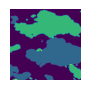

In [5]:
import torch

with rio.open(clean_img, 'r') as f:
    clean_data=torch.from_numpy(f.read())
    
with rio.open(cloudy_img, 'r') as f:
    cloudy_data=torch.from_numpy(f.read())
    
with rio.open(mask_img, 'r') as f:
    # Mask values: 0 - clear, 1 - cloudy, 2 - shadow,
    mask_data=torch.from_numpy(f.read())

for idx,img in enumerate(mask_data):
    plt.subplot(2,6,1+idx)
    plt.imshow(img)
    plt.axis('off')

print(np.unique(mask_data))
cmags=q_mag(reference=cloudy_data,mask=mask_data==0.0,mask_cloudy=mask_data==1.0,clean=clean_data,q=0.99,q2=0.5)
print(cmags)

Sentinel-2 range:  0.0354 0.902
Sentinel-3 range:  0.032 0.132
Landsat range:  0.0042489273473620415 0.3726334571838379
MODIS range:  -0.9999 -0.9999
VIIRS range:  0.0354 0.902
-9.999e-05 9.02e-05


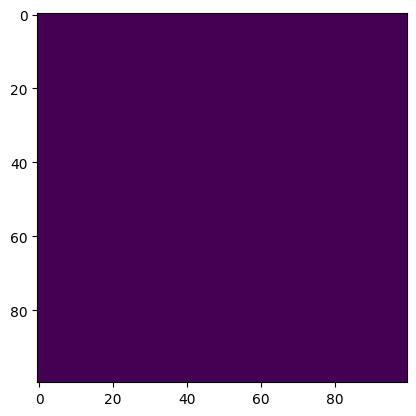

In [4]:
tif_path = "geotiffs/tiny_with_hr/LC09_20220807_FSC51_50.902331875635674_-117.13365599290965_with_preds(1).tif"

with rio.open(tif_path, 'r') as img:
    sen2_band_r = 272
    sen2_band_g = 271
    sen2_band_b = 270
    modis_band = 26
    sen3_band = 283
    landsat_band = 280
    sen2_band_r = (img.read(sen2_band_r) * 0.0001) 
    sen2_band_g = img.read(sen2_band_g) * 0.0001
    sen2_band_b = img.read(sen2_band_b) * 0.0001
    modis_band = img.read(modis_band) * 0.0001
    sen3_band = img.read(sen3_band) * 0.004
    landsat_band = img.read(landsat_band)
    plt.imshow(sen2_band_r)
    #plt.imshow(modis_band)

print("Sentinel-2 range: ", sen2_band_r.min(), sen2_band_r.max())
print("Sentinel-3 range: ", sen3_band.min(), sen3_band.max())
print("Landsat range: ", landsat_band.min(), landsat_band.max())
print("MODIS range: ", modis_band.min(), modis_band.max())
print("VIIRS range: ", sen2_band_r.min(), sen2_band_r.max())

composite = np.stack(arrays=[sen2_band_r, sen2_band_g, sen2_band_b, modis_band])
composite_switch = np.stack(arrays=[sen2_band_r, sen2_band_g, sen2_band_b], axis=-1)

rgb_img = (composite_switch - composite_switch.min()) / (composite_switch.max() - composite_switch.min())
plt.imshow(modis_band)

#plt.hist(composite.flatten())

composite = composite / 10000.0
print(composite.min(), composite.max())

0.238 0.718


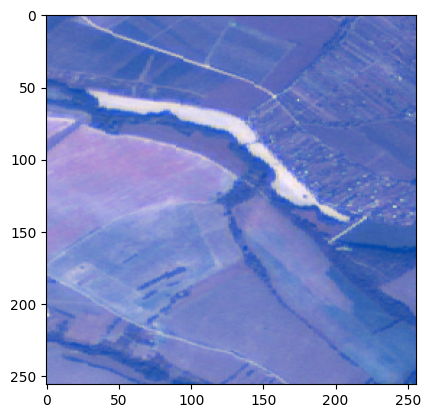

In [213]:
tif_path = "clean.tif"

with rio.open(tif_path, 'r') as img:
    sen2_band_r = 3
    sen2_band_g = 2
    sen2_band_b = 1
    sen2_band_r = img.read(sen2_band_r)
    sen2_band_g = img.read(sen2_band_g)
    sen2_band_b = img.read(sen2_band_b)
    #modis_band = img.read(modis_band)
    plt.imshow(sen2_band_r)
    #plt.imshow(modis_band)

composite = np.stack(arrays=[sen2_band_r, sen2_band_g, sen2_band_b])
composite_switch = np.stack(arrays=[sen2_band_r, sen2_band_g, sen2_band_b], axis=-1)

rgb_img = (composite_switch - composite_switch.min()) / (composite_switch.max() - composite_switch.min())
plt.imshow(rgb_img)
print(composite.min(), composite.max())

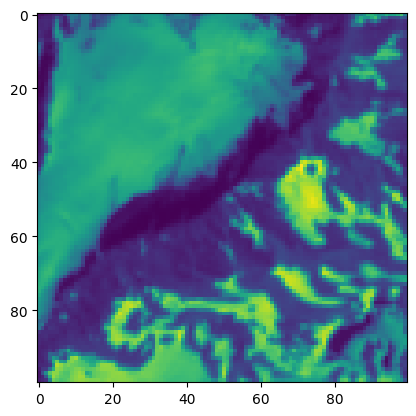

In [ ]:
def downsample_dynamic_in_time_with_mean(data, target_shape=(10, 10)):
    H, W = data.shape
    new_H, new_W = target_shape

    # Compute block sizes
    h_block = H // new_H
    w_block = W // new_W

    # reshape
    # for data, take the mean over blocks, for the mask take the min (we want the block mask to be invalid where at least one value is invalid)
    return data.reshape(new_H, h_block, new_W, w_block).mean(
        axis=(1, 3), dtype=data.dtype
    )

plt.imshow(sen2_band_r)

tensor(0.9568) tensor(0.)


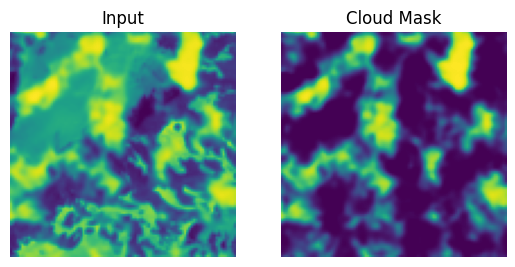

In [46]:
import random

cfgs = [scg.WIDE_CONFIG, scg.BIG_CONFIG, scg.LOCAL_CONFIG, scg.FOG_CONFIG]

gens = []

for cfg in cfgs:
    gens.append(scg.CloudGenerator(cfg, cloud_p=1.0, shadow_p=0.0))

gen = random.choice(gens)
out, mask, _ = gen(sen2_band_r, return_cloud=True)

plt.subplot(1,2,1)
plt.imshow(out[0][0])
plt.title('Input')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(mask[0][0])
plt.title('Cloud Mask')
plt.axis('off')

#plt.imshow(sen3_band)
print(mask.max(), mask.min())

In [47]:
print(out.max(), out.min())
print(sen2_band_r.max(), sen2_band_r.min())

tensor(0.9752) tensor(0.0404)
0.902 0.0354


tensor(0.1341) tensor(0.9922)
0.032 0.132
tensor(0.1341) tensor(0.9922)
torch.Size([100])
(array([0.13412312, 0.13544285, 0.13615379, ..., 0.9919056 , 0.9920438 ,
       0.99216306], dtype=float32), array([1, 1, 1, ..., 1, 1, 1], dtype=int64))
tensor(0.9874) tensor(0.0331)


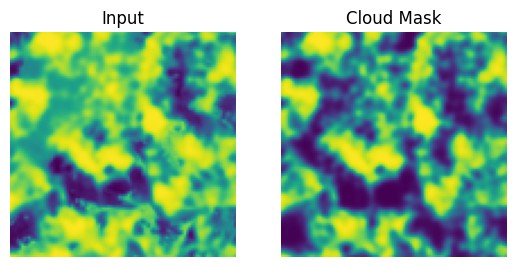

In [14]:
#sen3_band = composite
import torch
out, mask = scg.add_cloud(sen2_band_r,
                    return_cloud=True,
                    invert=False,
                    #channel_magnitude=torch.tensor([2.3711, 2.3064, 2.2686])
                    )

print(torch.clamp(out[0][0], 0.0, 1.0).min(), torch.clamp(out[0][0], 0.0, 1.0).max())
print(sen3_band.min(), sen3_band.max())
print(out[0].min(), out[0].max())
#
print(out[0][0][0].shape)
print(np.unique(out, return_counts=True))

#out_resampled = downsample_dynamic_in_time_with_mean(out[0][0][1], target_shape=(2,2))
#band_resampled = downsample_dynamic_in_time_with_mean(modis_band, target_shape=(2,2))

#plt.subplot(1,3,1)
#plt.imshow(out[0][0][2])
#plt.title('Input')
#plt.axis('off')
#plt.subplot(1,4,2)
#plt.imshow(band_resampled)
#plt.title('Input Resampled')
#plt.axis('off')
#plt.subplot(1,3,2)
#plt.imshow(out[0][0][0])
#plt.title('With cloud')
#plt.axis('off')
#plt.subplot(1,3,3)
#plt.imshow(out[0][0][1])
#plt.title('Cloud Resampled')
#plt.axis('off')

# show as rgb
#rgb = np.stack([out[0][0][0], out[0][0][1], out[0][0][2]], axis=-1)
#rgb_img = (rgb - rgb.min()) / (rgb.max() - rgb.min())

plt.subplot(1,2,1)
plt.imshow(out[0][0])
plt.title('Input')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(mask[0][0])
plt.title('Cloud Mask')
plt.axis('off')

#plt.imshow(sen3_band)
print(mask.max(), mask.min())

777.85754 10000.0


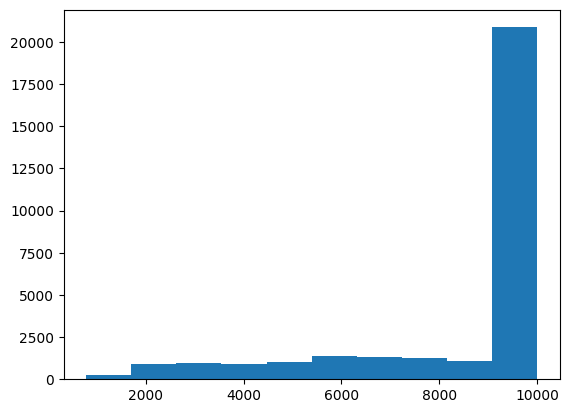

In [149]:
rgb = rgb.clip(0.0,1.0)  * 10000.0

# plot distribution of the rgb
plt.hist(rgb.flatten())
print(rgb.min(), rgb.max())

(-0.5, 99.5, 99.5, -0.5)

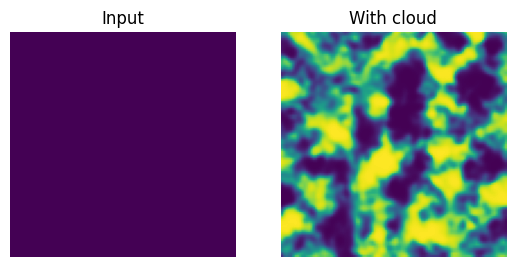

In [25]:
plt.subplot(1,2,1)
plt.imshow(sen2_band)
plt.title('Input')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(out[0][0][0])
plt.title('With cloud')
plt.axis('off')

In [10]:
"""
if timeseries_cloud_generation: 
    space_time_names = ["s_t_h_x", "s_t_m_x", "s_t_l_x"]
    space_time_vars = [space_time_high_res_x, space_time_med_res_x, space_time_low_res_x]
    to_cloud = []
    channel_slices = []

    for name, var in zip(space_time_names, space_time_vars):
        config = CHANNEL_WISE_CLOUD_PARAMETERS[name]
        apply_clouds_mask = []
        for sensor_cfg in config.values():
            apply_clouds_mask.extend(sensor_cfg["apply_clouds"])

        apply_clouds_mask = torch.tensor(apply_clouds_mask, dtype=torch.bool)
        # var shape: [H, W, T, C]
        x_no_last = var[:, :, :-1, :]  # [H, W, T-1, C]
        x_cloud_channels = x_no_last[:, :, :, apply_clouds_mask]  # [H, W, T-1, C_cloud]
        to_cloud.append(x_cloud_channels)

        # Save where these channels came from
        channel_slices.append(("spatial", var, apply_clouds_mask))

    # time-only
    config = CHANNEL_WISE_CLOUD_PARAMETERS["t_x"]
    apply_clouds_mask = []
    for sensor_cfg in config.values():
        apply_clouds_mask.extend(sensor_cfg["apply_clouds"])

    apply_clouds_mask = torch.tensor(apply_clouds_mask, dtype=torch.bool)
    # var shape: [T, C]
    x_no_last = time_x[:-1, :]  # [T-1, C]
    x_cloud_channels = x_no_last[apply_clouds_mask]  # [T-1, C_cloud]
    to_cloud.append(x_cloud_channels[None, None, :, :])  # [1, 1, T-1, C_cloud]

    channel_slices.append(("time", time_x, apply_clouds_mask))

        to_cloud_combined = torch.cat(to_cloud, dim=-1)
        x_cloud_in = to_cloud_combined.permute(3, 0, 1, 2)[None]

        # TODO: make that each timestep is fed in separately
        x_clouded = generate_clouds(x_cloud_in)
        x_clouded_hw_c = x_clouded[0].permute(1, 2, 0)

        c_start = 0
        for kind, tensor, mask in channel_slices:
            c_count = mask.sum().item()
            c_end = c_start + c_count

            cloud_chunk = x_clouded_hw_c[:, :, c_start:c_end]

            if kind == "spatial":
                # tensor shape: [H, W, T, C]
                tensor[:, :, -1, mask] = cloud_chunk

            elif kind == "time":
                # tensor shape: [T, C]
                tensor[-1, mask] = cloud_chunk[0, 0, :]

            c_start = c_end

"""

'\nif timeseries_cloud_generation: \n    space_time_names = ["s_t_h_x", "s_t_m_x", "s_t_l_x"]\n    space_time_vars = [space_time_high_res_x, space_time_med_res_x, space_time_low_res_x]\n    to_cloud = []\n    channel_slices = []\n\n    for name, var in zip(space_time_names, space_time_vars):\n        config = CHANNEL_WISE_CLOUD_PARAMETERS[name]\n        apply_clouds_mask = []\n        for sensor_cfg in config.values():\n            apply_clouds_mask.extend(sensor_cfg["apply_clouds"])\n\n        apply_clouds_mask = torch.tensor(apply_clouds_mask, dtype=torch.bool)\n        # var shape: [H, W, T, C]\n        x_no_last = var[:, :, :-1, :]  # [H, W, T-1, C]\n        x_cloud_channels = x_no_last[:, :, :, apply_clouds_mask]  # [H, W, T-1, C_cloud]\n        to_cloud.append(x_cloud_channels)\n\n        # Save where these channels came from\n        channel_slices.append(("spatial", var, apply_clouds_mask))\n\n    # time-only\n    config = CHANNEL_WISE_CLOUD_PARAMETERS["t_x"]\n    apply_clouds_